In [2]:
import os
from pathlib import Path
from typing import List, Dict, Any, Union

import torch
import torch.nn as nn
import numpy as np

from datasets import load_from_disk
from torch.utils.data import DataLoader

from transformers import (
    WhisperFeatureExtractor,
    WhisperTokenizerFast,
    WhisperProcessor,
    WhisperForConditionalGeneration,
)
import evaluate
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# ---- 경로 설정 (학습 때와 동일) ----
PROJECT_ROOT = Path("/home/alpaco/jws/whisper_only")
DATA_ROOT    = PROJECT_ROOT / "data"
PROC_DATA_DIR = DATA_ROOT / "ksponspeech_proc"
CKPT_ROOT   = PROJECT_ROOT / "checkpoints"   # checkpoint-* 폴더들

MODEL_NAME = "openai/whisper-small"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ---- 베이스 Whisper 모델에서 generation_config만 가져오기 (CPU) ----
print("[INFO] Load base generation_config from", MODEL_NAME)
_tmp_base = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)
BASE_GEN_CONFIG = _tmp_base.generation_config
del _tmp_base
torch.cuda.empty_cache()


/home/alpaco/anaconda3/envs/jws/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
[INFO] Load base generation_config from openai/whisper-small


In [3]:
class WhisperWithFillerHead(WhisperForConditionalGeneration):
    def __init__(self, config, class_weights=None):
        super().__init__(config)

        # decoder hidden state → 2-class (non-filler / filler)
        self.filler_classifier = nn.Linear(config.d_model, 2)

        # 항상 hidden states 출력
        self.config.output_hidden_states = True

        # class_weights는 버퍼로 들고 있지 않고,
        # loss 안에 weight로만 넘긴다 (state_dict 충돌 방지).
        if class_weights is not None:
            weight = torch.tensor(class_weights, dtype=torch.float32)
            self.filler_loss_fct = nn.CrossEntropyLoss(
                ignore_index=-100,
                weight=weight,
            )
        else:
            self.filler_loss_fct = nn.CrossEntropyLoss(
                ignore_index=-100,
            )

    def forward(
        self,
        input_features=None,
        attention_mask=None,
        decoder_input_ids=None,
        decoder_attention_mask=None,
        labels=None,
        filler_labels=None,
        **kwargs,
    ):
        # Trainer가 넘기는 num_items_in_batch는 제거
        if "num_items_in_batch" in kwargs:
            kwargs.pop("num_items_in_batch")

        # Whisper 기본 forward (ASR loss 포함)
        outputs = super().forward(
            input_features=input_features,
            attention_mask=attention_mask,
            decoder_input_ids=decoder_input_ids,
            decoder_attention_mask=decoder_attention_mask,
            labels=labels,
            **kwargs,
        )

        total_loss = outputs.loss
        filler_logits = None
        filler_loss = None

        # decoder hidden states → filler head
        if outputs.decoder_hidden_states is not None:
            last_hidden = outputs.decoder_hidden_states[-1]       # (B, T, d_model)
            filler_logits = self.filler_classifier(last_hidden)   # (B, T, 2)

            if filler_labels is not None:
                B, T, C = filler_logits.shape
                filler_loss = self.filler_loss_fct(
                    filler_logits.view(B * T, C),
                    filler_labels.view(B * T),
                )
                if total_loss is not None:
                    total_loss = total_loss + filler_loss
                else:
                    total_loss = filler_loss

        outputs.loss = total_loss
        outputs.filler_logits = filler_logits
        outputs.filler_loss = filler_loss
        return outputs


In [4]:
def patch_generation_config(model, processor):
    """
    - checkpoint에서 로드한 model.generation_config에
      Whisper generate()가 기대하는 필드를 채워 넣는다.
    - tokenizer.lang_to_id 같은 속성을 쓰지 않고,
      BASE_GEN_CONFIG에서 lang_to_id / task_to_id를 복사한다.
    """
    gen_cfg = model.generation_config

    # 언어/태스크 기본 설정
    gen_cfg.language = "korean"
    gen_cfg.task = "transcribe"

    # 베이스 generation_config에서 lang_to_id / task_to_id 복사
    # (checkpoint에 없으면 base 값으로 채운다)
    if not hasattr(gen_cfg, "lang_to_id") or gen_cfg.lang_to_id is None:
        gen_cfg.lang_to_id = BASE_GEN_CONFIG.lang_to_id
    if not hasattr(gen_cfg, "task_to_id") or gen_cfg.task_to_id is None:
        gen_cfg.task_to_id = BASE_GEN_CONFIG.task_to_id

    # forced_decoder_ids를 직접 설정해서 내부에서 lang_to_id를 쓰는 경로를 피함
    gen_cfg.forced_decoder_ids = processor.get_decoder_prompt_ids(
        language=gen_cfg.language,
        task=gen_cfg.task,
    )

    # pad/eos id도 안전하게 맞춰줌
    if getattr(gen_cfg, "pad_token_id", None) is None:
        gen_cfg.pad_token_id = BASE_GEN_CONFIG.pad_token_id
    if getattr(gen_cfg, "eos_token_id", None) is None:
        gen_cfg.eos_token_id = BASE_GEN_CONFIG.eos_token_id


In [5]:
feature_extractor = WhisperFeatureExtractor.from_pretrained(MODEL_NAME)
tokenizer = WhisperTokenizerFast.from_pretrained(
    MODEL_NAME,
    language="Korean",
    task="transcribe",
)
processor = WhisperProcessor(feature_extractor=feature_extractor,
                             tokenizer=tokenizer)

print("[INFO] Loading preprocessed KsponSpeech from:", PROC_DATA_DIR)
kspon_proc = load_from_disk(str(PROC_DATA_DIR))
print(kspon_proc)
print(kspon_proc["eval"][0].keys())   # 'input_features', 'labels', 'filler_labels'

kspon_eval = kspon_proc["eval"]


[INFO] Loading preprocessed KsponSpeech from: /home/alpaco/jws/whisper_only/data/ksponspeech_proc
DatasetDict({
    train: Dataset({
        features: ['input_features', 'labels', 'filler_labels'],
        num_rows: 299636
    })
    eval: Dataset({
        features: ['input_features', 'labels', 'filler_labels'],
        num_rows: 37454
    })
})
dict_keys(['input_features', 'labels', 'filler_labels'])


In [6]:
from dataclasses import dataclass

@dataclass
class DataCollatorWhisperWithFiller:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], np.ndarray]]]) -> Dict[str, torch.Tensor]:
        # 1) audio input_features
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(
            input_features, return_tensors="pt"
        )

        # 2) labels (ASR 토큰)
        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(
            label_features, return_tensors="pt"
        )

        labels = labels_batch["input_ids"]
        attention_mask = labels_batch["attention_mask"]

        # pad → -100
        labels = labels.masked_fill(attention_mask.ne(1), -100)
        batch["labels"] = labels

        # 3) filler_labels
        filler_lists = [f["filler_labels"] for f in features]
        max_len = labels.shape[1]

        padded_filler = []
        for fl in filler_lists:
            fl = list(fl)
            pad_len = max_len - len(fl)
            padded = fl + [-100] * pad_len
            padded_filler.append(padded[:max_len])

        filler_labels = torch.tensor(padded_filler, dtype=torch.long)
        filler_labels = filler_labels.masked_fill(attention_mask.ne(1), -100)

        batch["filler_labels"] = filler_labels
        return batch

data_collator = DataCollatorWhisperWithFiller(processor=processor)


In [7]:
wer_metric = evaluate.load("wer")

def evaluate_asr_wer(
    model: WhisperWithFillerHead,
    dataset,
    max_samples: int = 1000,
    max_length: int = 225,
):
    """
    - dataset: kspon_eval
    - max_samples: 평가에 사용할 샘플 수
    """
    model.eval()
    preds = []
    refs = []

    for idx, ex in enumerate(dataset):
        if idx >= max_samples:
            break

        # (80, T) → (1, 80, T)
        feat = torch.tensor(ex["input_features"], dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            gen_ids = model.generate(
                input_features=feat,
                max_length=max_length,
            )

        # 예측 텍스트
        pred_text = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)[0]

        # 정답 텍스트: labels의 -100 → pad_token_id 후 decode
        label_ids = np.array(ex["labels"], dtype=np.int64)
        label_ids[label_ids == -100] = tokenizer.pad_token_id
        ref_text = tokenizer.decode(label_ids, skip_special_tokens=True)

        preds.append(pred_text)
        refs.append(ref_text)

    wer = 100 * wer_metric.compute(predictions=preds, references=refs)
    return {"wer": wer, "n_samples": len(preds)}


In [8]:
def eval_filler_head(
    model: WhisperWithFillerHead,
    dataset,
    processor: WhisperProcessor,
    device: torch.device,
    max_batches: int = 100,
    batch_size: int = 8,
):
    model.eval()
    dl = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=DataCollatorWhisperWithFiller(processor=processor),
    )

    all_true = []
    all_pred = []

    for b_idx, batch in enumerate(dl):
        if b_idx >= max_batches:
            break

        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.no_grad():
            outputs = model(**batch)
            filler_logits = outputs.filler_logits   # (B, T, 2)

        if filler_logits is None:
            print("[WARN] filler_logits is None.")
            return None

        # (B, T, 2) → (B, T)
        filler_pred = filler_logits.argmax(dim=-1)  # 0=non-filler, 1=filler
        filler_labels = batch["filler_labels"]

        # 평탄화 + pad(-100) 제거
        y_true = filler_labels.view(-1).cpu().numpy()
        y_pred = filler_pred.view(-1).cpu().numpy()

        mask = (y_true != -100)
        y_true = y_true[mask]
        y_pred = y_pred[mask]

        if y_true.size == 0:
            continue

        all_true.append(y_true)
        all_pred.append(y_pred)

    if not all_true:
        print("[WARN] No valid tokens for filler evaluation.")
        return None

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[1], average=None, zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)

    return {
        "precision_filler": float(precision[0]),
        "recall_filler": float(recall[0]),
        "f1_filler": float(f1[0]),
        "accuracy": float(acc),
        "n_tokens": int(len(y_true)),
    }


In [24]:
# checkpoint-* 디렉토리 찾기
ckpts = []
if CKPT_ROOT.exists():
    for p in sorted(CKPT_ROOT.iterdir(), key=lambda x: x.name):
        if p.is_dir() and p.name.startswith("checkpoint-"):
            ckpts.append(p)

if not ckpts:
    print("[ERROR] No checkpoint-* directories found in", CKPT_ROOT)
else:
    print("[INFO] Found checkpoints:")
    for p in ckpts:
        print("  ", p)

ASR_MAX_SAMPLES_CANDIDATE       = 1000
FILLER_MAX_BATCHES_CANDIDATE    = 50
FILLER_BATCH_SIZE_CANDIDATE     = 8

results = []

for ckpt_dir in ckpts:
    print("\n===============================================")
    print(f"[INFO] Evaluating checkpoint: {ckpt_dir}")
    print("===============================================")

    # 1) 모델 로드
    model = WhisperWithFillerHead.from_pretrained(str(ckpt_dir))

    # 2) generation_config 패치
    patch_generation_config(model, processor)

    model.to(device)
    model.eval()

    # 3) ASR WER (부분 eval)
    print("[ASR] Evaluating WER on", ASR_MAX_SAMPLES_CANDIDATE, "samples...")
    asr_metrics = evaluate_asr_wer(
        model,
        kspon_eval,
        max_samples=ASR_MAX_SAMPLES_CANDIDATE,
    )
    print("[ASR] WER(candidate):", asr_metrics)

    # 4) filler metrics (부분 eval)
    print("[FILLER] Evaluating filler metrics on",
          FILLER_MAX_BATCHES_CANDIDATE, "batches...")
    filler_metrics = eval_filler_head(
        model=model,
        dataset=kspon_eval,
        processor=processor,
        device=device,
        max_batches=FILLER_MAX_BATCHES_CANDIDATE,
        batch_size=FILLER_BATCH_SIZE_CANDIDATE,
    )
    print("[FILLER] candidate metrics:", filler_metrics)

    rec = {
        "checkpoint": str(ckpt_dir),
        "wer": float(asr_metrics["wer"]) if asr_metrics is not None else None,
        "n_samples_asr": int(asr_metrics["n_samples"]) if asr_metrics is not None else 0,
    }
    if filler_metrics is not None:
        rec.update(filler_metrics)
    results.append(rec)

print("\n[INFO] Candidate evaluation summary:")
for r in results:
    print(r)

# WER 기준 best, filler F1 기준 best 둘 다 보기
best_by_wer = min(
    (r for r in results if r["wer"] is not None),
    key=lambda x: x["wer"],
)
best_by_f1 = max(
    (r for r in results if "f1_filler" in r and r["f1_filler"] is not None),
    key=lambda x: x["f1_filler"],
)

print("\n[INFO] Best checkpoint by WER:")
print(best_by_wer)
print("\n[INFO] Best checkpoint by filler F1:")
print(best_by_f1)

# 실제 사용할 checkpoint 선택
BEST_CKPT = best_by_wer["checkpoint"]  # 필요하면 best_by_f1["checkpoint"]로 바꿔도 됨
print("\n[INFO] Selected BEST_CKPT:", BEST_CKPT)


[INFO] Found checkpoints:
   /home/alpaco/jws/whisper_only/checkpoints/checkpoint-2000
   /home/alpaco/jws/whisper_only/checkpoints/checkpoint-4000
   /home/alpaco/jws/whisper_only/checkpoints/checkpoint-4689

[INFO] Evaluating checkpoint: /home/alpaco/jws/whisper_only/checkpoints/checkpoint-2000


Some weights of the model checkpoint at /home/alpaco/jws/whisper_only/checkpoints/checkpoint-2000 were not used when initializing WhisperWithFillerHead: ['filler_loss_fct.weight']
- This IS expected if you are initializing WhisperWithFillerHead from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WhisperWithFillerHead from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
`generation_config` default values have been modified to match model-specific defaults: {'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9

[ASR] Evaluating WER on 1000 samples...


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

[ASR] WER(candidate): {'wer': 47.04576976421637, 'n_samples': 1000}
[FILLER] Evaluating filler metrics on 50 batches...


...

[FILLER] candidate metrics: {'precision_filler': 0.23423423423423423, 'recall_filler': 0.975, 'f1_filler': 0.37772397094430993, 'accuracy': 0.9730183727034121, 'n_tokens': 9525}

[INFO] Evaluating checkpoint: /home/alpaco/jws/whisper_only/checkpoints/checkpoint-4000


Some weights of the model checkpoint at /home/alpaco/jws/whisper_only/checkpoints/checkpoint-4000 were not used when initializing WhisperWithFillerHead: ['filler_loss_fct.weight']
- This IS expected if you are initializing WhisperWithFillerHead from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WhisperWithFillerHead from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


[ASR] Evaluating WER on 1000 samples...
[ASR] WER(candidate): {'wer': 41.55339805825243, 'n_samples': 1000}
[FILLER] Evaluating filler metrics on 50 batches...
[FILLER] candidate metrics: {'precision_filler': 0.2792452830188679, 'recall_filler': 0.925, 'f1_filler': 0.4289855072463768, 'accuracy': 0.9793175853018373, 'n_tokens': 9525}

[INFO] Evaluating checkpoint: /home/alpaco/jws/whisper_only/checkpoints/checkpoint-4689


Some weights of the model checkpoint at /home/alpaco/jws/whisper_only/checkpoints/checkpoint-4689 were not used when initializing WhisperWithFillerHead: ['filler_loss_fct.weight']
- This IS expected if you are initializing WhisperWithFillerHead from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WhisperWithFillerHead from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


[ASR] Evaluating WER on 1000 samples...
[ASR] WER(candidate): {'wer': 41.84003698566806, 'n_samples': 1000}
[FILLER] Evaluating filler metrics on 50 batches...
[FILLER] candidate metrics: {'precision_filler': 0.2792452830188679, 'recall_filler': 0.925, 'f1_filler': 0.4289855072463768, 'accuracy': 0.9793175853018373, 'n_tokens': 9525}

[INFO] Candidate evaluation summary:
{'checkpoint': '/home/alpaco/jws/whisper_only/checkpoints/checkpoint-2000', 'wer': 47.04576976421637, 'n_samples_asr': 1000, 'precision_filler': 0.23423423423423423, 'recall_filler': 0.975, 'f1_filler': 0.37772397094430993, 'accuracy': 0.9730183727034121, 'n_tokens': 9525}
{'checkpoint': '/home/alpaco/jws/whisper_only/checkpoints/checkpoint-4000', 'wer': 41.55339805825243, 'n_samples_asr': 1000, 'precision_filler': 0.2792452830188679, 'recall_filler': 0.925, 'f1_filler': 0.4289855072463768, 'accuracy': 0.9793175853018373, 'n_tokens': 9525}
{'checkpoint': '/home/alpaco/jws/whisper_only/checkpoints/checkpoint-4689', 'wer

In [25]:
ASR_MAX_SAMPLES_FINAL        = 2000
FILLER_MAX_BATCHES_FINAL     = 200
FILLER_BATCH_SIZE_FINAL      = 8

print("\n===============================================")
print("[INFO] Final evaluation with BEST_CKPT:", BEST_CKPT)
print("===============================================")

best_model = WhisperWithFillerHead.from_pretrained(BEST_CKPT)
patch_generation_config(best_model, processor)
best_model.to(device)
best_model.eval()

print("\n[INFO] Final ASR evaluation on eval split...")
final_asr = evaluate_asr_wer(
    best_model,
    kspon_eval,
    max_samples=ASR_MAX_SAMPLES_FINAL,
)
print("[INFO] Final ASR metrics:", final_asr)

print("\n[INFO] Final FILLER HEAD evaluation on eval split...")
final_filler = eval_filler_head(
    best_model,
    kspon_eval,
    processor=processor,
    device=device,
    max_batches=FILLER_MAX_BATCHES_FINAL,
    batch_size=FILLER_BATCH_SIZE_FINAL,
)
print("[INFO] Final FILLER metrics:", final_filler)

print("\n[INFO] BEST_CKPT (for inference notebook):")
print(BEST_CKPT)



[INFO] Final evaluation with BEST_CKPT: /home/alpaco/jws/whisper_only/checkpoints/checkpoint-4000


Some weights of the model checkpoint at /home/alpaco/jws/whisper_only/checkpoints/checkpoint-4000 were not used when initializing WhisperWithFillerHead: ['filler_loss_fct.weight']
- This IS expected if you are initializing WhisperWithFillerHead from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WhisperWithFillerHead from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



[INFO] Final ASR evaluation on eval split...
[INFO] Final ASR metrics: {'wer': 43.51026379554702, 'n_samples': 2000}

[INFO] Final FILLER HEAD evaluation on eval split...
[INFO] Final FILLER metrics: {'precision_filler': 0.2980132450331126, 'recall_filler': 0.9292035398230089, 'f1_filler': 0.4512893982808023, 'accuracy': 0.9796135625698621, 'n_tokens': 37574}

[INFO] BEST_CKPT (for inference notebook):
/home/alpaco/jws/whisper_only/checkpoints/checkpoint-4000


In [ ]:
# ===== 특정 체크포인트 하나를 지정해서 WER / filler metric 평가 =====

# 1) 평가할 checkpoint 경로 지정
#    예: checkpoint-4000 을 보고 싶으면 아래처럼 변경
CKPT_TO_EVAL = "/home/alpaco/jws/whisper_only/final_model_stage2p"

print("[INFO] Single checkpoint evaluation target:")
print("   ", CKPT_TO_EVAL)

# 2) 모델 로드 + generation_config 패치
single_model = WhisperWithFillerHead.from_pretrained(CKPT_TO_EVAL)
patch_generation_config(single_model, processor)

single_model.to(device)
single_model.eval()

# 3) ASR WER 평가
ASR_MAX_SAMPLES_SINGLE   = 1000   # 필요하면 조절
print(f"\n[ASR] Evaluating WER on {ASR_MAX_SAMPLES_SINGLE} samples for:", CKPT_TO_EVAL)
single_asr = evaluate_asr_wer(
    single_model,
    kspon_eval,
    max_samples=ASR_MAX_SAMPLES_SINGLE,
)
print("[ASR] Single checkpoint ASR metrics:", single_asr)

# 4) filler head 평가
FILLER_MAX_BATCHES_SINGLE = 100   # 필요하면 조절
FILLER_BATCH_SIZE_SINGLE  = 8

print(f"\n[FILLER] Evaluating filler metrics on {FILLER_MAX_BATCHES_SINGLE} batches for:", CKPT_TO_EVAL)
single_filler = eval_filler_head(
    model=single_model,
    dataset=kspon_eval,
    processor=processor,
    device=device,
    max_batches=FILLER_MAX_BATCHES_SINGLE,
    batch_size=FILLER_BATCH_SIZE_SINGLE,
)
print("[FILLER] Single checkpoint filler metrics:", single_filler)


The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[INFO] Single checkpoint evaluation target:
    /home/alpaco/jws/whisper_only/final_model_stage2p


Some weights of the model checkpoint at /home/alpaco/jws/whisper_only/final_model_stage2p were not used when initializing WhisperWithFillerHead: ['filler_classifier.0.bias', 'filler_classifier.0.weight', 'filler_classifier.3.bias', 'filler_classifier.3.weight', 'filler_loss_fct.weight']
- This IS expected if you are initializing WhisperWithFillerHead from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WhisperWithFillerHead from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of WhisperWithFillerHead were not initialized from the model checkpoint at /home/alpaco/jws/whisper_only/final_model_stage2p and are newly initialized: ['filler_classifier.bias', 'filler_classifier.weight']
You should prob


[ASR] Evaluating WER on 1000 samples for: /home/alpaco/jws/whisper_only/final_model_stage2p


`generation_config` default values have been modified to match model-specific defaults: {'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}. If this is not desired, please set these values explicitly.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logit

[ASR] Single checkpoint ASR metrics: {'wer': 40.99861303744799, 'n_samples': 1000}

[FILLER] Evaluating filler metrics on 100 batches for: /home/alpaco/jws/whisper_only/final_model_stage2p


You're using a WhisperTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


[FILLER] Single checkpoint filler metrics: {'precision_filler': 0.004403623553095118, 'recall_filler': 0.19662921348314608, 'f1_filler': 0.008614324390844204, 'accuracy': 0.5673934056492321, 'n_tokens': 18622}


: 

In [32]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# kspon_eval, processor, device, DataCollatorWhisperWithFiller 가 이미 정의되어 있다고 가정
kspon_eval = kspon_proc["eval"]

# 학습 때와 동일한 collator 사용
data_collator_eval = DataCollatorWhisperWithFiller(processor=processor)

def collect_filler_probs_and_labels(
    model,
    dataset,
    processor,
    device,
    max_batches: int = 200,
    batch_size: int = 8,
):
    """
    모델에서 filler_logits → softmax 확률까지 구해서
    P(filler)와 정답 라벨을 모두 모으는 함수.
    이걸 한 번만 실행하고, threshold는 나중에 따로 스윕.
    """
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=data_collator_eval,
    )

    all_true = []
    all_prob = []   # P(filler)

    model.eval()
    with torch.no_grad():
        for b_idx, batch in enumerate(loader):
            if max_batches is not None and b_idx >= max_batches:
                break

            batch = {
                k: (v.to(device) if isinstance(v, torch.Tensor) else v)
                for k, v in batch.items()
            }

            outputs = model(
                input_features=batch["input_features"],
                labels=batch["labels"],
                filler_labels=batch["filler_labels"],
            )

            filler_logits = outputs.filler_logits  # (B, T, 2)
            if filler_logits is None:
                print("[WARN] filler_logits is None.")
                return None, None

            probs = filler_logits.softmax(dim=-1)[..., 1]  # (B, T) filler 확률
            filler_labels = batch["filler_labels"]         # (B, T)

            y_true = filler_labels.view(-1).cpu().numpy()
            y_prob = probs.view(-1).cpu().numpy()

            mask = (y_true != -100)
            y_true = y_true[mask]
            y_prob = y_prob[mask]

            if y_true.size == 0:
                continue

            all_true.append(y_true)
            all_prob.append(y_prob)

    if not all_true:
        print("[WARN] No valid tokens for filler evaluation.")
        return None, None

    y_true = np.concatenate(all_true)
    y_prob = np.concatenate(all_prob)
    print(f"[INFO] collected tokens: {len(y_true)}")

    return y_true, y_prob


In [33]:
def eval_thresholds_on_probs(y_true, y_prob, thresholds):
    """
    이미 모아둔 y_true, y_prob 에 대해
    여러 threshold에서 precision/recall/F1/accuracy 계산.
    """
    results = []
    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[1], average=None, zero_division=0
        )
        acc = accuracy_score(y_true, y_pred)

        rec = {
            "threshold": th,
            "precision_filler": float(precision[0]),
            "recall_filler": float(recall[0]),
            "f1_filler": float(f1[0]),
            "accuracy": float(acc),
        }
        results.append(rec)
    return pd.DataFrame(results)


[INFO] Single checkpoint evaluation target:
    /home/alpaco/jws/whisper_only/checkpoints_stage2/checkpoint-3126


Some weights of the model checkpoint at /home/alpaco/jws/whisper_only/checkpoints_stage2/checkpoint-3126 were not used when initializing WhisperWithFillerHead: ['filler_loss_fct.weight']
- This IS expected if you are initializing WhisperWithFillerHead from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WhisperWithFillerHead from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


[INFO] collected tokens: 37574

=== Threshold sweep results (filler token-level) ===


,threshold,precision_filler,recall_filler,f1_filler,accuracy
0,0.3,0.359302,0.911504,0.515430,0.984537
1,0.4,0.380228,0.884956,0.531915,0.985948
2,0.5,0.412256,0.873156,0.560076,0.987624
3,0.6,0.440860,0.846608,0.579798,0.988929
4,0.7,0.477876,0.796460,0.597345,0.990312


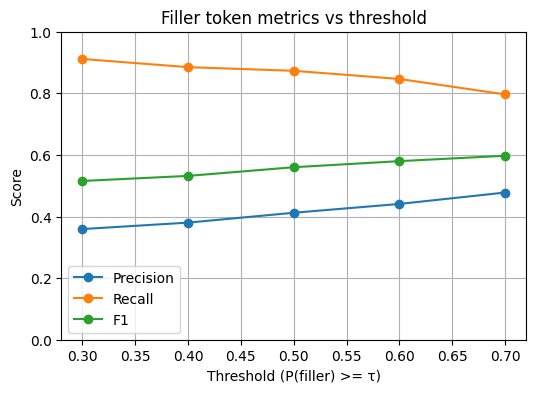

: 

In [ ]:
# 1) 평가할 checkpoint 지정 (원하는 걸로 바꿔서 사용)
CKPT_TO_EVAL = "/home/alpaco/jws/whisper_only/checkpoints_stage2/checkpoint-3126"

print("[INFO] Single checkpoint evaluation target:")
print("   ", CKPT_TO_EVAL)

# 2) 모델 로드 (학습 때와 동일한 WhisperWithFillerHead 정의가 노트북에 있어야 함)
model = WhisperWithFillerHead.from_pretrained(CKPT_TO_EVAL)
model.to(device)

# 3) eval split 에서 확률/정답 수집
y_true, y_prob = collect_filler_probs_and_labels(
    model=model,
    dataset=kspon_eval,
    processor=processor,
    device=device,
    max_batches=200,   # 필요하면 100/300 등으로 조절
    batch_size=8,
)

# 4) 여러 threshold에서 metric 계산
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
df_th = eval_thresholds_on_probs(y_true, y_prob, thresholds)

print("\n=== Threshold sweep results (filler token-level) ===")
display(df_th)

# 5) 그래프로 시각화
plt.figure(figsize=(6,4))
plt.plot(df_th["threshold"], df_th["precision_filler"], marker="o", label="Precision")
plt.plot(df_th["threshold"], df_th["recall_filler"],    marker="o", label="Recall")
plt.plot(df_th["threshold"], df_th["f1_filler"],        marker="o", label="F1")
plt.xlabel("Threshold (P(filler) >= τ)")
plt.ylabel("Score")
plt.ylim(0.0, 1.0)
plt.grid(True)
plt.legend()
plt.title("Filler token metrics vs threshold")
plt.show()
